In [26]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation
from tensorflow.keras.optimizers import RMSprop, SGD
from tensorflow.keras import regularizers, initializers
import numpy as np
import matplotlib.pyplot as plt

In [15]:
#Definimos los parámetros
learning_rate = 0.1
epochs = 30
batch_size = 10
num_classes = 10
mu = 0.4

In [16]:
#Descargamos los datos
dataset=mnist.load_data()

In [17]:
#Definimos el conjunto de entrenamiento y prueba
(x_train, y_train), (x_test, y_test) = dataset

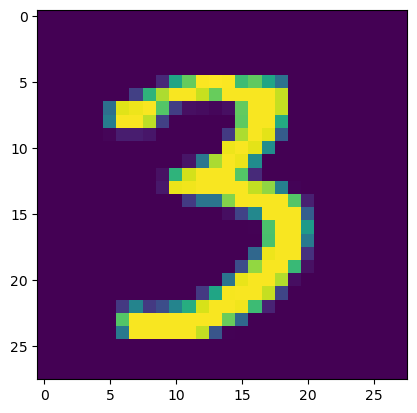

In [18]:
#Imagen de ejemplo
plt.imshow(x_train[10000])

In [19]:
#Dimensiones de entrenamiento
x_train.shape

(60000, 28, 28)

In [20]:
#Aplanar a 784 y escalar a [0,1]
x_trainv = x_train.reshape(60000, 784)
x_testv = x_test.reshape(10000, 784)
x_trainv = x_trainv.astype('float32')
x_testv = x_testv.astype('float32')

x_trainv /= 255.  # x_trainv = x_trainv/255
x_testv /= 255.

In [21]:
#Ejemplo de y_train
print(y_train[10000])

3


In [22]:
#One-hot encoding
y_trainc = keras.utils.to_categorical(y_train, num_classes)
y_testc = keras.utils.to_categorical(y_test, num_classes)

In [23]:
#Ejemplo de la visualización de y_trainc para el mismo dígito
y_trainc[10000]

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

In [29]:
model = Sequential([
    keras.Input(shape=(784,)),  #Capa de entrada
    
    #Hidden layer de 30 neuronas, con activación sigmoide
    Dense(30, activation='sigmoid',
    #Inicializamos los pesos de manera optimizada (784 input)
    kernel_initializer=initializers.RandomNormal(mean=0.0, stddev=1.0/np.sqrt(784)),
    bias_initializer=initializers.RandomNormal(mean=0.0, stddev=1.0)),
    
    #Hidden layer de num_classes (10) neuronas, con activación sigmoide
    Dense(num_classes, activation='sigmoid',  #Capa de salida (10 neuronas)
    #Inicializamos los pesos de manera optimizada (30 input de la capa anterior)
    kernel_initializer=initializers.RandomNormal(mean=0.0, stddev=1.0/np.sqrt(30)),
    bias_initializer=initializers.RandomNormal(mean=0.0, stddev=1.0))
])

In [30]:
#Como optimizador usamos SGD+momentum, con el learning rate y momentum definidos
opt = SGD(learning_rate=learning_rate, momentum=mu, nesterov=False)
#Utilizamos binary_crossentropy como función de costo y como métrica categorical_accuracy
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['categorical_accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 30)             │        23,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           310 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,860 (93.20 KB)

 Trainable params: 23,860 (93.20 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history = model.fit(x_trainv, y_trainc,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_testv, y_testc)
                    )

Epoch 1/30
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 42s 6ms/step - categorical_accuracy: 0.7800 - loss: 0.1619 - val_categorical_accuracy: 0.8839 - val_loss: 0.0933
Epoch 2/30
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - categorical_accuracy: 0.8940 - loss: 0.0805 - val_categorical_accuracy: 0.9074 - val_loss: 0.0684
Epoch 3/30
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - categorical_accuracy: 0.9094 - loss: 0.0649 - val_categorical_accuracy: 0.9184 - val_loss: 0.0590
Epoch 4/30
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step - categorical_accuracy: 0.9173 - loss: 0.0575 - val_categorical_accuracy: 0.9226 - val_loss: 0.0536
Epoch 5/30
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 35s 6ms/step - categorical_accuracy: 0.9233 - loss: 0.0529 - val_categorical_accuracy: 0.9282 - val_loss: 0.0501
Epoch 6/30
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - categorical_accuracy: 0.9282 - loss: 0.0495 - val_categorical_accuracy: 0.9315 - val_loss: 0.0476
Epoch 7/30
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step - categorical_a

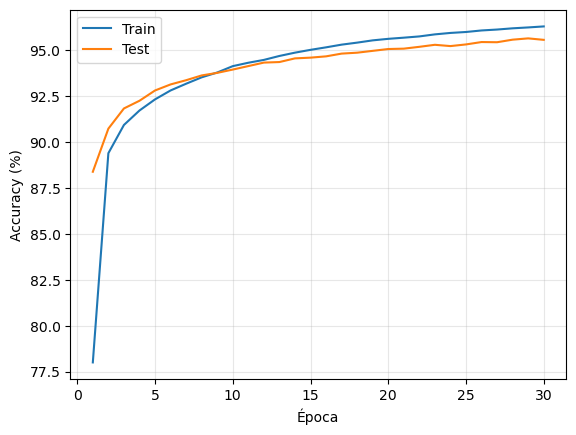

In [46]:
#Graficar accuracy
train_acc = np.array(history.history['categorical_accuracy']) * 100
val_acc   = np.array(history.history['val_categorical_accuracy']) * 100
ep_range  = np.arange(1, len(train_acc) + 1)

plt.figure()
plt.plot(ep_range, train_acc, label='Train')
plt.plot(ep_range, val_acc,   label='Test')
plt.xlabel('Época')
plt.ylabel('Accuracy (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()